# Political Competition and Voter Turnout in South African Local Elections, 2000-2021
### Exploratory Data Analysis 

**Our question:** does voter turnout follow an *inverted U* against political competition? We expect turnout to be low where one party dominates (voters see the result as decided), highest in competitive "battleground" municipalities, and low again where the council is split among many parties (coalition fatigue).

**What this notebook does**
1. Loads the five local government elections (2000, 2006, 2011, 2016, 2021) and harmonises them into one schema.
2. Audits and fixes data-quality problems, logging every change.
3. Links municipalities across elections despite boundary changes, producing a municipality × election panel.
4. Engineers competition features (Effective Number of Parties, dominance, margin) and turnout.
5. Explores trends over time, then tests the inverted U both *between* municipalities and *within* the same municipality over time.

**Data source:** Electoral Commission of South Africa (IEC), municipal election results - https://results.elections.org.za/home/downloads/me-results

## 1. Setup

In [1]:
# Core libraries for data handling, statistics and plotting.
# We fix the random seed so every rerun of the notebook gives identical results.
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import statsmodels.formula.api as smf
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
RNG = np.random.default_rng(42)

# One fixed colour per province and per election so every chart reads the same way.
PROVINCE_COLOURS = {
    "Eastern Cape": "#1b9e77", "Free State": "#d95f02", "Gauteng": "#7570b3",
    "KwaZulu-Natal": "#e7298a", "Limpopo": "#66a61e", "Mpumalanga": "#e6ab02",
    "North West": "#a6761d", "Northern Cape": "#666666", "Western Cape": "#1f78b4",
}
YEARS = [2000, 2006, 2011, 2016, 2021]
print(f"pandas {pd.__version__} | numpy {np.__version__}")

pandas 3.0.2 | numpy 2.4.4


In [2]:
# Paths are relative to the project folder, so the notebook runs on any computer after cloning.
# It works whether Jupyter is opened in the notebooks/ folder or in the project root.
PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_DIR / "data" / "cleaned"
FIG_DIR = PROJECT_DIR / "figures"
OUT_DIR = PROJECT_DIR / "outputs"
for folder in (FIG_DIR, OUT_DIR):
    folder.mkdir(parents=True, exist_ok=True)

HIST_FILES = {2000: "2000_LGE_Cleaned.csv", 2006: "2006_LGE_Cleaned.csv",
              2011: "2011_LGE_Cleaned.csv", 2016: "2016_LGE_Cleaned.csv"}
FILE_2021 = "LGE2021_Cleaned_Level.csv.zip"   # zipped to stay under GitHub's 100 MB limit; pandas reads it directly
EXCEL_ROW_LIMIT = 1_048_576

# We stop early with a clear message if any file is missing, rather than failing halfway.
missing = [f for f in [*HIST_FILES.values(), FILE_2021] if not (DATA_DIR / f).exists()]
assert not missing, f"Missing files: {missing}"
print("All five election files found. If any are missing, run the 01_cleaning notebooks first.")

All five election files found. If any are missing, run the 01_cleaning notebooks first.


## 2. Loading the five elections
The 2000–2016 files are already at **municipality × party × ballot** level with an IEC turnout figure. The 2021 file is at **voting-district** level, so we aggregate it to the same level and compute turnout ourselves.

In [3]:
# The four historical files share one layout but name their columns slightly differently.
# We map them onto one common schema so all elections can be stacked into a single table.
SCHEMA = ["year", "province", "municipality", "party", "ballot", "valid_votes", "turnout"]
COLUMN_MAP = {"Province": "province", "Municipality": "municipality", "Party": "party",
              "Ballot Type": "ballot", "BallotType": "ballot", "ValidVotesCast": "valid_votes",
              "MeanVoterTurnout": "turnout", "% Voter Turnout": "turnout"}

def load_historical(year: int, fname: str) -> pd.DataFrame:
    # Reads one historical election file and returns it in the common schema.
    df = pd.read_csv(DATA_DIR / fname, index_col=0).rename(columns=COLUMN_MAP)
    df.insert(0, "year", year)
    return df[SCHEMA]

hist = pd.concat([load_historical(y, f) for y, f in HIST_FILES.items()], ignore_index=True)
print(f"2000–2016 loaded: {len(hist):,} rows")

2000–2016 loaded: 12,030 rows


In [4]:
# 2021 is at voting-district level; registered and spoilt votes repeat on every party row,
# so we take them once per district before summing to municipality level.
cols = ["Province", "Municipality", "VotingDistrict", "RegisteredVoters",
        "BallotType", "SpoiltVotes", "PartyName", "TotalValidVotes"]
raw21 = pd.read_csv(DATA_DIR / FILE_2021, usecols=cols, dtype={"VotingDistrict": "string"})

# Completeness check. An earlier version combined the provinces in Excel, which cut the file off at
# 1,048,576 rows and lost most of the Western Cape; 01_cleaning_2021 now combines them in code.
n_munis = raw21["Municipality"].nunique()
n_wc = raw21.loc[raw21["Province"] == "Western Cape", "Municipality"].nunique()
print(f"2021 rows: {len(raw21):,} (Excel's limit is {EXCEL_ROW_LIMIT:,}) | municipalities: {n_munis} | Western Cape: {n_wc}")
assert n_munis == 213 and n_wc == 25, "2021 data is incomplete: rerun 01_cleaning_2021.ipynb"

pr21 = raw21[raw21["BallotType"] == "PR"]
vd21 = (pr21.groupby(["Municipality", "VotingDistrict"], observed=True)
            .agg(registered=("RegisteredVoters", "first"), spoilt=("SpoiltVotes", "first"),
                 valid=("TotalValidVotes", "sum")).reset_index())
turnout21 = (vd21.groupby("Municipality", observed=True)[["registered", "spoilt", "valid"]].sum()
                 .assign(turnout=lambda d: (d["valid"] + d["spoilt"]) / d["registered"] * 100)
                 .reset_index())

# We reshape 2021 into the same municipality × party layout as the older files.
lge21 = (pr21.groupby(["Province", "Municipality", "PartyName"], observed=True)["TotalValidVotes"].sum()
             .reset_index()
             .rename(columns={"Province": "province", "Municipality": "municipality",
                              "PartyName": "party", "TotalValidVotes": "valid_votes"})
             .merge(turnout21[["Municipality", "turnout"]].rename(columns={"Municipality": "municipality"}),
                    on="municipality", validate="many_to_one")
             .assign(year=2021, ballot="PR")[SCHEMA])
print(f"2021 aggregated: {len(lge21):,} municipality × party rows")

2021 rows: 1,084,734 (Excel's limit is 1,048,576) | municipalities: 213 | Western Cape: 25


2021 aggregated: 2,789 municipality × party rows


In [5]:
# We stack all five elections and tidy the text fields (stray spaces, mixed upper/lower case).
# Result: one long table, one row per election × municipality × party × ballot.
lge = pd.concat([hist, lge21], ignore_index=True)
for c in ["province", "municipality", "party", "ballot"]:
    lge[c] = lge[c].astype(str).str.strip().str.replace(r"\s+", " ", regex=True)
lge["party"] = lge["party"].str.upper()
lge["ballot"] = lge["ballot"].str.upper()
print(f"Combined table: {len(lge):,} rows × {lge.shape[1]} columns")
lge.sample(5, random_state=1)

Combined table: 14,819 rows × 7 columns


,year,province,municipality,party,ballot,valid_votes,turnout
12418,2021,Free State,FS184 - Matjhabeng,PATRIOTIC ALLIANCE,PR,515,44.351615
2007,2000,Western Cape,WC041 - Kannaland [Ladismith],DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE,PR,3359,69.530000
14420,2021,Northern Cape,NC452 - GA-SEGONYANA,SOUTH AFRICAN ROYAL KINGDOMS ORGANIZATION,PR,501,43.348786
9564,2016,KwaZulu-Natal,KZN227 - Richmond,PEOPLE'S REVOLUTIONARY MOVEMENT,WARD,61,45.180000
106,2000,Eastern Cape,EC125 - Buffalo City [East London],PAN AFRICANIST CONGRESS OF AZANIA,WARD,4089,62.180000


## 3. Data-quality audit
Before changing anything we profile each election. Turnout outside 0–100%, unexpected ballot types or odd municipality counts all point to problems.

In [6]:
# One row per election: size, coverage, ballot types and the turnout range.
# Anything unusual here becomes a documented fix in the next cells.
per_muni = lge.drop_duplicates(["year", "municipality"])
audit = (lge.groupby("year")
            .agg(rows=("party", "size"), municipalities=("municipality", "nunique"),
                 parties=("party", "nunique"),
                 ballot_types=("ballot", lambda s: " | ".join(sorted(s.unique()))))
            .join(per_muni.groupby("year")["turnout"].agg(turnout_min="min", turnout_median="median",
                                                          turnout_max="max").round(2)))
audit

,rows,municipalities,parties,ballot_types,turnout_min,turnout_median,turnout_max
year,,,,,,,
2000,2083,261,80,DMA DC 60% | PR | WARD,0.00,52.95,92.70
2006,2931,256,98,DMA DC 60% | PR | PROTEA CITY AND GREENSIDE RE...,14.29,53.11,7387.58
2011,3281,234,122,PR | WARD,44.94,60.30,80.18
2016,3735,213,206,PR | WARD,22.58,35.88,60.43
2021,2789,213,312,PR,36.33,48.21,70.69


The audit flags four problems: turnout of **0%** (2000) and **7,387%** (2006), a stray ballot type in 2006 that is actually a residents' association name, and a **2016 median turnout of ~36%**, far below the ~58% the IEC reported nationally for 2016. We fix each one below and record it in a cleaning log.

In [7]:
# Municipality labels look like "EC101 - Camdeboo [Graaff-Reinet]"; we split out code and name.
# In 2000 the metros used city names instead of codes, so we map them to today's metro codes.
METRO_ALIAS = {"Port Elizabeth": "NMA", "East Rand": "EKU", "Johannesburg": "JHB",
               "Pretoria": "TSH", "Durban": "ETH", "Cape Town": "CPT"}
METROS = {"BUF", "NMA", "MAN", "EKU", "JHB", "TSH", "ETH", "CPT"}

parts = lge["municipality"].str.extract(r"^(?P<code>[^\[]+?)(?: - (?P<name>[^\[]+?))?\s*(?:\[.*\])?$")
lge["code"] = parts["code"].str.strip().replace(METRO_ALIAS)
lge["name"] = parts["name"].fillna(parts["code"]).str.strip()

# 2000 and 2006 used "KZ" and "NP" (Northern Province) prefixes; later years use "KZN" and "LIM".
# We standardise the prefixes so the same municipality keeps the same code across elections.
lge["code"] = (lge["code"].str.replace(r"^KZ(?=\d)", "KZN", regex=True)
                          .str.replace(r"^NP(?=\d)", "LIM", regex=True))
lge["is_dma"] = lge["code"].str.contains(r"DMA\d*$", regex=True)
print(f"Parsed {lge['code'].nunique():,} distinct codes; {lge.loc[lge['is_dma'], 'code'].nunique()} are DMAs.")

Parsed 312 distinct codes; 25 are DMAs.


In [8]:
# Every fix is logged with the rows it touched, so the cleaning is transparent and auditable.
cleaning_log = []
def log_fix(years, issue, rows, action):
    cleaning_log.append({"election(s)": years, "issue": issue, "rows affected": int(rows), "action": action})

# Fix 1: District Management Areas are nature reserves and parks with very few voters.
# They are not municipalities in the usual sense and produce extreme turnout (e.g. 0%).
mask = lge["is_dma"]
log_fix(", ".join(map(str, sorted(lge.loc[mask, "year"].unique()))),
        "District Management Areas (parks/reserves)", mask.sum(), "Dropped")
lge = lge[~mask]

# Fix 2: one 2006 row has a residents' association name shifted into the ballot column.
# We keep only genuine ballot types.
VALID_BALLOTS = {"PR", "WARD", "DMA DC 60%"}
mask = ~lge["ballot"].isin(VALID_BALLOTS)
log_fix(", ".join(map(str, sorted(lge.loc[mask, "year"].unique()))),
        "Misaligned row: text in ballot column", mask.sum(), "Dropped")
lge = lge[~mask]

# Fix 3: turnout above 100% is impossible (2006 Johannesburg shows 7,387.58%).
# We blank it so that municipality still counts for competition but not for turnout.
mask = (lge["turnout"] <= 0) | (lge["turnout"] > 100)
log_fix(", ".join(map(str, sorted(lge.loc[mask, "year"].unique()))),
        "Impossible turnout (≤0% or >100%)", mask.sum(), "Turnout set to missing")
lge.loc[mask, "turnout"] = np.nan

# Fix 4: the DA appears under its bilingual name before 2016 and its short name after.
# One consistent name lets us track which party leads each council over time.
PARTY_ALIAS = {"DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE": "DEMOCRATIC ALLIANCE"}
lge["party"] = lge["party"].str.replace(r"\s*/\s*", "/", regex=True)
mask = lge["party"].isin(PARTY_ALIAS)
log_fix(", ".join(map(str, sorted(lge.loc[mask, "year"].unique()))),
        "Same party under different names", mask.sum(), "Names harmonised")
lge["party"] = lge["party"].replace(PARTY_ALIAS)
print(f"Rows remaining: {len(lge):,}")

Rows remaining: 14,704


### Is every year's turnout really *votes ÷ registered voters*?
If turnout = valid votes ÷ denominator, then **valid votes ÷ turnout** gives back the denominator the file used. For the same municipality, registered voters grow slowly between elections, so that implied denominator should change by a modest ratio. Normal voter-roll growth gives ratios of roughly 1.1–1.2×; a much larger jump means the column is not votes ÷ registered voters. (The cause, found by tracing the check below back to `01_cleaning_2016`, is that the 2016 column divides only the **leading party's** votes by registered voters.)

In [9]:
# We recover each file's implied denominator from PR valid votes and turnout.
# Registered voters only grow gradually, so consecutive elections should give ratios near 1.
pr_only = lge[lge["ballot"] == "PR"]
denom = (pr_only.groupby(["year", "code"])
                .agg(valid=("valid_votes", "sum"), turnout=("turnout", "first"))
                .assign(implied_denominator=lambda d: d["valid"] / (d["turnout"] / 100))
                ["implied_denominator"].unstack("year"))

pairs = list(zip(YEARS[:-1], YEARS[1:]))
ratio_check = pd.DataFrame({f"{a}→{b}": (denom[b] / denom[a]).describe()[["count", "25%", "50%", "75%"]]
                            for a, b in pairs}).T.round(2)
ratio_check.columns = ["matched municipalities", "ratio 25th pct", "median ratio", "ratio 75th pct"]
display(ratio_check)

# The metros make the problem easy to see: 2016 denominators are 2–3× larger than 2011.
display((denom.loc[sorted(METROS), [2011, 2016, 2021]] / 1e6).round(2)
             .rename(columns=lambda y: f"{y} implied denominator (millions)"))

,matched municipalities,ratio 25th pct,median ratio,ratio 75th pct
2000→2006,220.0,1.07,1.14,1.22
2006→2011,213.0,1.07,1.13,1.20
2011→2016,199.0,1.58,1.79,2.11
2016→2021,213.0,0.54,0.62,0.70


year,2011 implied denominator (millions),2016 implied denominator (millions),2021 implied denominator (millions)
code,,,
BUF,0.36,0.70,0.40
CPT,1.70,2.96,1.95
EKU,1.35,3.25,1.55
ETH,1.60,3.25,1.87
JHB,1.90,4.99,2.19
MAN,0.36,0.75,0.40
NMA,0.55,1.30,0.58
TSH,1.25,3.51,1.51


In [10]:
# If 2016 denominators jump far beyond normal voter-roll growth, 2016 "turnout" is not turnout.
# We then blank 2016 turnout; 2016 competition measures (vote shares) remain fully usable.
median_jump = (denom[2016] / denom[2011]).median()
if median_jump > 1.5:
    rows = (lge["year"] == 2016).sum()
    lge.loc[lge["year"] == 2016, "turnout"] = np.nan
    log_fix("2016", f"Column is not turnout (implied denominator {median_jump:.2f}× 2011's): it is the leading "
                    "party's votes ÷ registered voters (see 01_cleaning_2016)", rows, "Turnout set to missing")
    print(f"2016 turnout excluded: implied denominator is {median_jump:.2f}× the 2011 value.")

cleaning_log = pd.DataFrame(cleaning_log)
cleaning_log.to_csv(OUT_DIR / "cleaning_log.csv", index=False)
cleaning_log

2016 turnout excluded: implied denominator is 1.79× the 2011 value.


,election(s),issue,rows affected,action
0,"2000, 2006",District Management Areas (parks/reserves),114,Dropped
1,2006,Misaligned row: text in ballot column,1,Dropped
2,2006,Impossible turnout (≤0% or >100%),35,Turnout set to missing
3,"2000, 2006, 2011",Same party under different names,1317,Names harmonised
4,2016,Column is not turnout (implied denominator 1.7...,3735,Turnout set to missing


## 4. Linking municipalities across elections
Municipal boundaries were redrawn before the 2006, 2011 and 2016 elections, and some municipalities were renamed, so one place can appear under different codes or names. We treat two records as the **same municipality if they share a code *or* the same province + cleaned name**, and chain these links together. Each linked group takes its most recent code as its panel ID.

In [11]:
# We normalise names so "Buffalo City Metropolitan Municipality" matches "Buffalo City".
# Some 2000 records carry only a code as their name, so those are linked by code alone.
def name_key(name: str) -> str:
    s = name.lower()
    s = re.sub(r"\b(metropolitan municipality|local municipality|municipality|metro|city of)\b", " ", s)
    return re.sub(r"[^a-z0-9]", "", s)

pr = lge[lge["ballot"] == "PR"].copy()
munis = (pr.drop_duplicates(["year", "municipality"])[["year", "province", "municipality", "code", "name"]]
           .reset_index(drop=True))
munis["name_key"] = munis["province"] + "|" + munis["name"].map(name_key)
munis["placeholder_name"] = munis["name"].map(name_key).str.fullmatch(r"[a-z]{2,3}\d+[a-z]?\d*")

# Union-find: records sharing a code or a name key end up in the same connected group.
parent = {}
def find(x):
    parent.setdefault(x, x)
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x
def union(a, b):
    parent[find(a)] = find(b)

for i, r in munis.iterrows():
    union(("record", i), ("code", r["code"]))
    if not r["placeholder_name"]:
        union(("record", i), ("name", r["name_key"]))
munis["group"] = [find(("record", i)) for i in munis.index]
latest = munis.sort_values("year").groupby("group")["code"].last()
munis["panel_id"] = munis["group"].map(latest)

# Safety check: a linked group must never contain two municipalities from the same election.
# Any group that does is split back to plain code matching.
clash_groups = munis.loc[munis.duplicated(["group", "year"], keep=False), "group"].unique()
clash = munis["group"].isin(clash_groups)
munis.loc[clash, "panel_id"] = munis.loc[clash, "code"]
assert not munis.duplicated(["year", "panel_id"]).any(), "Duplicate panel IDs remain"
print(f"{munis['panel_id'].nunique()} panel municipalities from {len(munis)} municipality-election records "
      f"({clash.sum()} records in ambiguous groups fell back to code matching).")

pr = pr.merge(munis[["year", "municipality", "panel_id"]], on=["year", "municipality"], validate="many_to_one")

263 panel municipalities from 1134 municipality-election records (10 records in ambiguous groups fell back to code matching).


In [12]:
# How well does the panel hold together? Units seen in more elections give stronger evidence.
# Within-municipality tests later only use units with at least two usable turnout figures.
appearances = munis.groupby("panel_id")["year"].nunique()
coverage = appearances.value_counts().sort_index().rename_axis("elections appeared in").to_frame("municipalities")
display(coverage)
display(munis.groupby("year")["panel_id"].nunique().to_frame("municipalities (PR ballot)").T)

,municipalities
elections appeared in,
1,12
2,17
3,36
4,10
5,188


year,2000,2006,2011,2016,2021
municipalities (PR ballot),237,237,234,213,213


## 5. Feature engineering: one row per municipality per election
All competition measures use the **PR ballot**, the party vote for the whole municipal council.

| Feature | Meaning |
|---|---|
| `enp` | Effective Number of Parties = 1 ÷ Σ(share²). Two equal parties → 2.0; one party at 90% → ≈1.2 |
| `hhi` | Herfindahl index = Σ(share²): concentration of the vote |
| `top_share` | Leading party's vote share (dominance) |
| `margin` | Gap between first and second party (closeness of the race) |
| `turnout` | % of registered voters who voted |
| `log_valid` | log₁₀ of total valid votes: municipality size (descriptive only, see note) |

In [13]:
# Party vote shares within each municipality and election.
# Shares are the building block for every competition measure below.
votes = pr.groupby(["year", "panel_id", "party"])["valid_votes"].sum().reset_index()
votes["share"] = votes["valid_votes"] / votes.groupby(["year", "panel_id"])["valid_votes"].transform("sum")

def competition_metrics(g: pd.DataFrame) -> pd.Series:
    # Summarises one municipality-election's party shares into competition measures.
    s = np.sort(g["share"].to_numpy())[::-1]
    return pd.Series({
        "enp": 1 / np.sum(s ** 2),
        "hhi": np.sum(s ** 2),
        "top_share": s[0],
        "margin": s[0] - (s[1] if len(s) > 1 else 0),
        "parties_contesting": int((g["valid_votes"] > 0).sum()),
        "leading_party": g.loc[g["share"].idxmax(), "party"],
        "total_valid": g["valid_votes"].sum(),
    })

comp = votes.groupby(["year", "panel_id"]).apply(competition_metrics).reset_index()

In [14]:
# We attach turnout, province and a readable name, then add controls and regimes.
# BUF and MAN only became metros in 2011, so the metro flag depends on the year.
info = (pr.groupby(["year", "panel_id"])
          .agg(province=("province", "first"), turnout=("turnout", "first")).reset_index())
latest_name = munis.sort_values("year").groupby("panel_id")["name"].last()

panel = comp.merge(info, on=["year", "panel_id"], validate="one_to_one")
panel["name"] = panel["panel_id"].map(latest_name)
panel["log_valid"] = np.log10(panel["total_valid"].astype(float))
panel["metro"] = (panel["panel_id"].isin(METROS)
                  & ~(panel["panel_id"].isin({"BUF", "MAN"}) & (panel["year"] < 2011))).astype(int)
for c in ["enp", "hhi", "top_share", "margin"]:
    panel[c] = panel[c].astype(float)

# Fixed thresholds let us compare regimes across elections on the same scale.
panel["regime"] = pd.cut(panel["enp"], bins=[0, 2, 3, np.inf], right=False,
                         labels=["Dominant (ENP < 2)", "Competitive (2–3)", "Fragmented (ENP ≥ 3)"])
panel = panel[["year", "panel_id", "name", "province", "metro", "turnout", "enp", "hhi", "top_share",
               "margin", "parties_contesting", "leading_party", "total_valid", "log_valid", "regime"]]
print(f"Panel: {len(panel):,} municipality-elections | {panel['panel_id'].nunique()} municipalities")
panel.head()

Panel: 1,134 municipality-elections | 263 municipalities


,year,panel_id,name,province,metro,turnout,enp,hhi,top_share,margin,parties_contesting,leading_party,total_valid,log_valid,regime
0,2000,BUF,Buffalo City,Eastern Cape,0,62.18,1.472733,0.679010,0.812671,0.680152,6,AFRICAN NATIONAL CONGRESS,194108,5.288043,Dominant (ENP < 2)
1,2000,CBLC1,Kuruman-Mothibistad,Northern Cape,0,48.74,2.055852,0.486416,0.652690,0.471964,3,AFRICAN NATIONAL CONGRESS,14071,4.148325,Competitive (2–3)
2,2000,CBLC3,Greater Marble Hall,Mpumalanga,0,48.05,1.413513,0.707457,0.835651,0.753783,5,AFRICAN NATIONAL CONGRESS,19629,4.292898,Dominant (ENP < 2)
3,2000,CBLC4,Greater Groblersdal,Mpumalanga,0,49.39,1.423368,0.702559,0.833845,0.766989,6,AFRICAN NATIONAL CONGRESS,40071,4.602830,Dominant (ENP < 2)
4,2000,CBLC5,Greater Tubatse,Mpumalanga,0,48.09,1.227978,0.814347,0.900443,0.857187,4,AFRICAN NATIONAL CONGRESS,42237,4.625693,Dominant (ENP < 2)


In [15]:
# A one-glance summary of each election: turnout, fragmentation and dominance.
# The ANC share of councils shows how single-party dominance has changed since 2000.
summary = (panel.groupby("year")
                .agg(municipalities=("panel_id", "size"),
                     turnout_median=("turnout", "median"),
                     enp_median=("enp", "median"),
                     top_share_median=("top_share", "median"),
                     pct_led_by_ANC=("leading_party", lambda s: (s == "AFRICAN NATIONAL CONGRESS").mean() * 100),
                     pct_dominant=("regime", lambda s: (s == "Dominant (ENP < 2)").mean() * 100),
                     pct_fragmented=("regime", lambda s: (s == "Fragmented (ENP ≥ 3)").mean() * 100))
                .round(2))
summary

,municipalities,turnout_median,enp_median,top_share_median,pct_led_by_ANC,pct_dominant,pct_fragmented
year,,,,,,,
2000,237,52.94,1.83,0.70,74.68,69.62,1.27
2006,237,53.39,1.74,0.74,85.65,66.24,3.80
2011,234,60.30,1.86,0.70,86.32,59.83,3.42
2016,213,NaN,2.13,0.63,83.57,36.62,3.29
2021,213,48.21,2.59,0.55,79.34,16.43,30.99


## 6. How competition and turnout have changed, 2000–2021

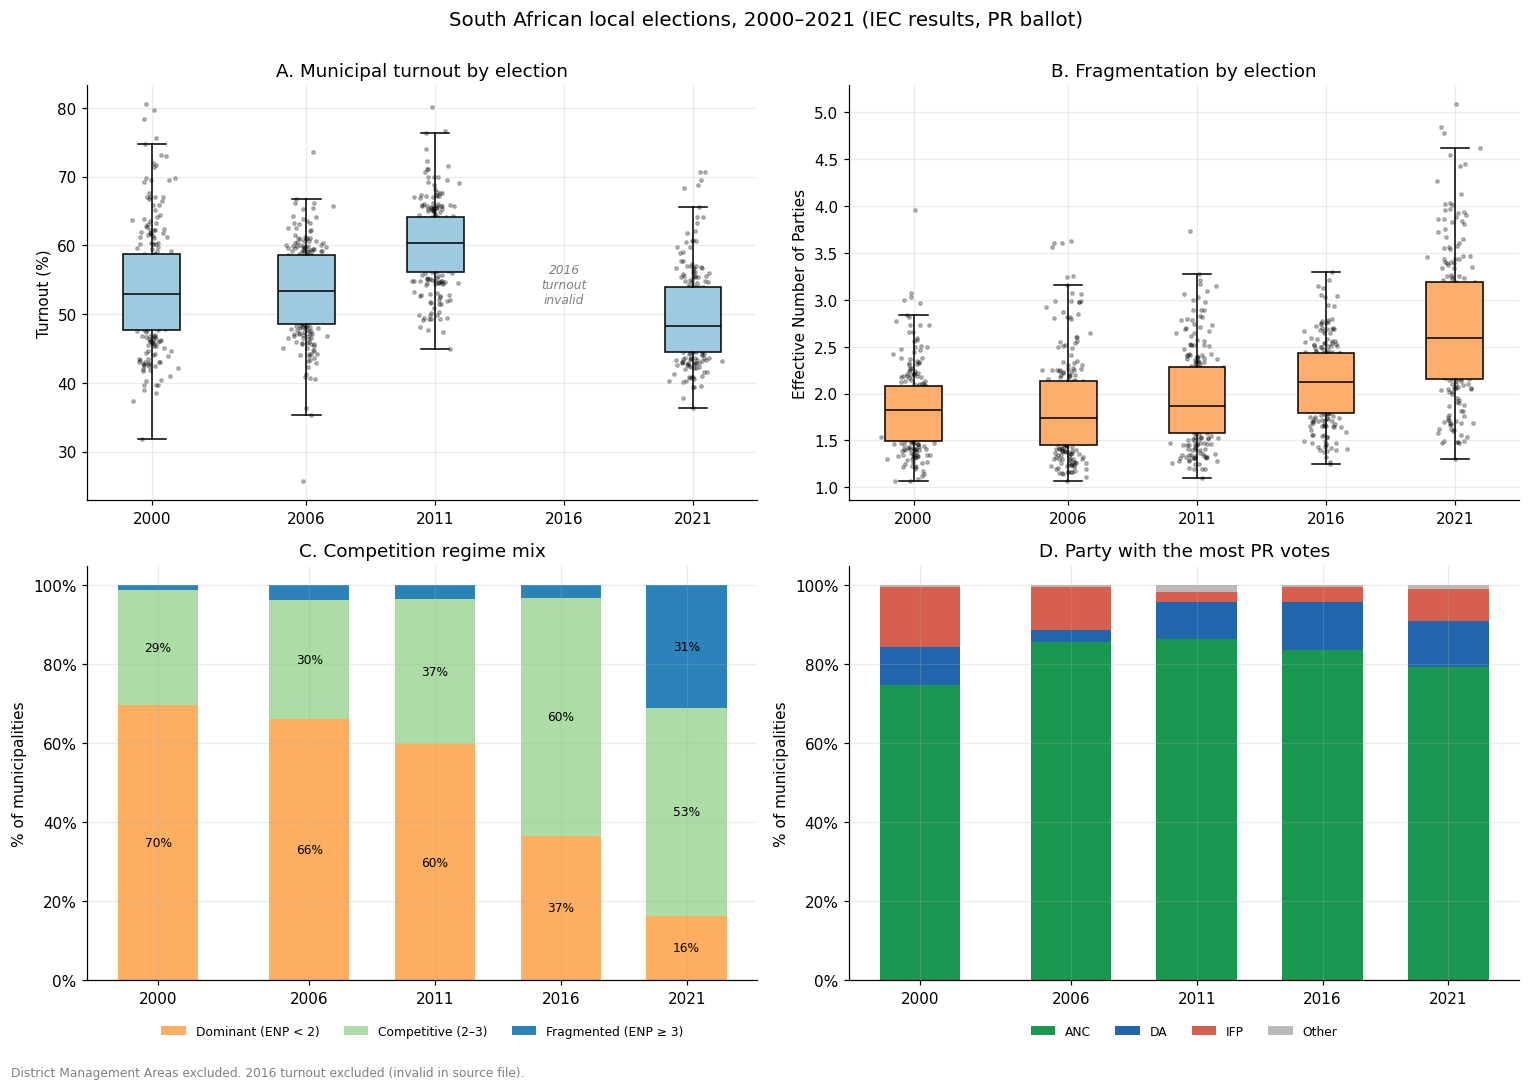

In [16]:
# Four views of the same 21 years: turnout, fragmentation, regime mix and who leads councils.
# 2016 has no turnout panel because that file's turnout column was shown to be invalid.
fig, axes = plt.subplots(2, 2, figsize=(14, 9.5))
turnout_years = [y for y in YEARS if panel.loc[panel["year"] == y, "turnout"].notna().any()]

ax = axes[0, 0]
data = [panel.loc[panel["year"] == y, "turnout"].dropna() for y in turnout_years]
bp = ax.boxplot(data, positions=turnout_years, widths=2.2, patch_artist=True, showfliers=False,
                medianprops=dict(color="black"))
for patch in bp["boxes"]:
    patch.set_facecolor("#9ecae1")
for y, d in zip(turnout_years, data):
    ax.scatter(np.full(len(d), y) + RNG.normal(0, 0.35, len(d)), d, s=5, color="black", alpha=0.25)
ax.text(2016, np.nanmedian(panel["turnout"]), "2016\nturnout\ninvalid", ha="center", va="center",
        fontsize=8, color="grey", style="italic")
ax.set(xlim=(1997.5, 2023.5), ylabel="Turnout (%)", title="A. Municipal turnout by election")
ax.set_xticks(YEARS, labels=YEARS)

ax = axes[0, 1]
data = [panel.loc[panel["year"] == y, "enp"] for y in YEARS]
bp = ax.boxplot(data, positions=YEARS, widths=2.2, patch_artist=True, showfliers=False,
                medianprops=dict(color="black"))
for patch in bp["boxes"]:
    patch.set_facecolor("#fdae6b")
for y, d in zip(YEARS, data):
    ax.scatter(np.full(len(d), y) + RNG.normal(0, 0.35, len(d)), d, s=5, color="black", alpha=0.25)
ax.set(xlim=(1997.5, 2023.5), ylabel="Effective Number of Parties", title="B. Fragmentation by election")
ax.set_xticks(YEARS, labels=YEARS)

ax = axes[1, 0]
regime_share = pd.crosstab(panel["year"], panel["regime"], normalize="index") * 100
bottom = np.zeros(len(regime_share))
for col, colour in zip(regime_share.columns, ["#fdae61", "#abdda4", "#2b83ba"]):
    ax.bar(regime_share.index, regime_share[col], bottom=bottom, width=3.2, color=colour, label=col)
    for x, b, v in zip(regime_share.index, bottom, regime_share[col]):
        if v > 6:
            ax.text(x, b + v / 2, f"{v:.0f}%", ha="center", va="center", fontsize=8)
    bottom += regime_share[col].to_numpy()
ax.set(xticks=YEARS, ylabel="% of municipalities", title="C. Competition regime mix")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False)

ax = axes[1, 1]
top_parties = {"AFRICAN NATIONAL CONGRESS": "ANC", "DEMOCRATIC ALLIANCE": "DA",
               "INKATHA FREEDOM PARTY": "IFP"}
leader = panel["leading_party"].map(top_parties).fillna("Other")
lead_share = pd.crosstab(panel["year"], leader, normalize="index")[["ANC", "DA", "IFP", "Other"]] * 100
bottom = np.zeros(len(lead_share))
for col, colour in zip(lead_share.columns, ["#1a9850", "#2166ac", "#d6604d", "#bababa"]):
    ax.bar(lead_share.index, lead_share[col], bottom=bottom, width=3.2, color=colour, label=col)
    bottom += lead_share[col].to_numpy()
ax.set(xticks=YEARS, ylabel="% of municipalities", title="D. Party with the most PR votes")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=4, frameon=False)

fig.suptitle("South African local elections, 2000–2021 (IEC results, PR ballot)", fontsize=13, y=1.0)
fig.text(0.01, -0.02, "District Management Areas excluded. 2016 turnout excluded (invalid in source file).",
         fontsize=8, color="grey")
plt.tight_layout()
fig.savefig(FIG_DIR / "01_trends_2000_2021.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Turnout vs fragmentation, election by election
Each panel is one election. The black line is a quadratic fit (our inverted-U hypothesis); the red dashed line is LOWESS, a smoother that assumes no shape and acts as an honesty check.

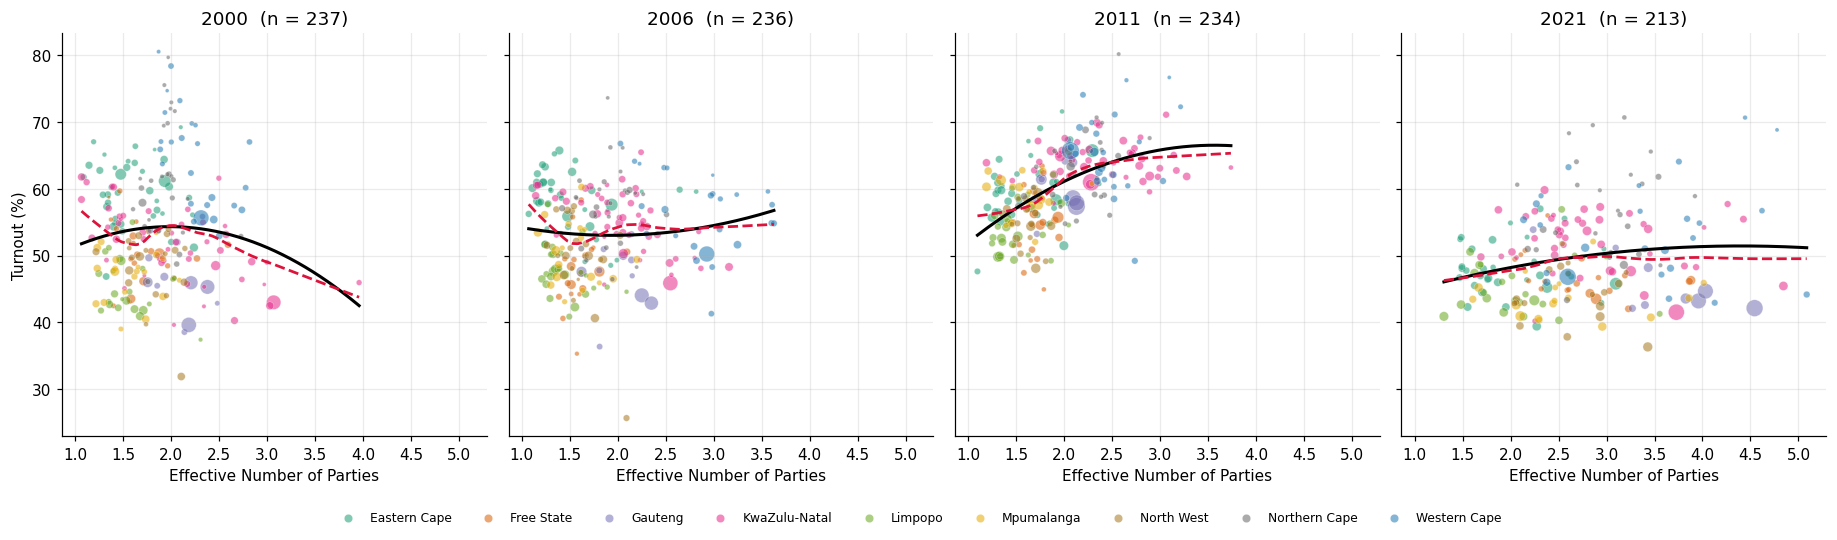

In [17]:
# One panel per election with turnout data, sharing the same axes for fair comparison.
# Point size reflects the number of valid votes, so large municipalities stand out.
fig, axes = plt.subplots(1, len(turnout_years), figsize=(4.2 * len(turnout_years), 4.6), sharey=True, sharex=True)
for ax, y in zip(axes, turnout_years):
    d = panel[(panel["year"] == y)].dropna(subset=["turnout"])
    for prov, g in d.groupby("province"):
        ax.scatter(g["enp"], g["turnout"], s=np.sqrt(g["total_valid"].astype(float)) / 8,
                   c=PROVINCE_COLOURS.get(prov, "grey"), alpha=0.55, edgecolor="white", linewidth=0.3,
                   label=prov)
    grid = np.linspace(d["enp"].min(), d["enp"].max(), 150)
    ax.plot(grid, np.polyval(np.polyfit(d["enp"], d["turnout"], 2), grid), color="black", lw=2)
    sm = lowess(d["turnout"], d["enp"], frac=0.6)
    ax.plot(sm[:, 0], sm[:, 1], color="crimson", lw=1.8, ls="--")
    ax.set(title=f"{y}  (n = {len(d)})", xlabel="Effective Number of Parties")
axes[0].set_ylabel("Turnout (%)")
handles, labels = axes[0].get_legend_handles_labels()
leg = fig.legend(handles, labels, loc="lower center", ncol=9, fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.07))
for h in leg.legend_handles:
    h.set_sizes([30])
plt.tight_layout()
fig.savefig(FIG_DIR / "02_turnout_vs_enp_by_year.png", dpi=200, bbox_inches="tight")
plt.show()

In [18]:
def lind_mehlum(model, xmin, xmax, var="enp"):
    # Lind & Mehlum (2010) test: an inverted U needs a significantly positive slope at the low end
    # and a significantly negative slope at the high end. We also report the p-value for a normal U.
    sq = f"I({var} ** 2)"
    b1, b2 = model.params[var], model.params[sq]
    V = model.cov_params().loc[[var, sq], [var, sq]].to_numpy()
    def slope_t(x0):
        g = np.array([1, 2 * x0])
        return (b1 + 2 * b2 * x0) / np.sqrt(g @ V @ g)
    t_lo, t_hi = slope_t(xmin), slope_t(xmax)
    tp = -b1 / (2 * b2) if b2 != 0 else np.nan
    return pd.Series({"β enp": b1, "β enp²": b2, "slope t (low end)": t_lo, "slope t (high end)": t_hi,
                      "turning point (ENP)": tp, "turning point in data": bool(xmin < tp < xmax),
                      "inverted-U p-value": stats.norm.sf(min(t_lo, -t_hi)),
                      "U-shape p-value": stats.norm.sf(min(-t_lo, t_hi))})

# We run the same quadratic test separately for each election with turnout data.
# If the inverted U is real, it should show up consistently rather than in one year only.
per_year = {}
for y in turnout_years:
    d = panel[panel["year"] == y].dropna(subset=["turnout"])
    m = smf.ols("turnout ~ enp + I(enp**2)", data=d).fit(cov_type="HC3")
    per_year[y] = pd.concat([pd.Series({"n": int(m.nobs), "R²": m.rsquared}),
                             lind_mehlum(m, d["enp"].min(), d["enp"].max())])
per_year = pd.DataFrame(per_year).T
per_year

,n,R²,β enp,β enp²,slope t (low end),slope t (high end),turning point (ENP),turning point in data,inverted-U p-value,U-shape p-value
2000,237.0,0.013747,12.031908,-3.034722,1.550717,-1.848045,1.982374,True,0.060485,0.967702
2006,236.0,0.007932,-5.084956,1.310717,-0.993398,1.71626,1.939761,True,0.956943,0.160258
2011,234.0,0.301554,15.751975,-2.208319,4.821629,-0.21388,3.566508,True,0.41532,0.999999
2021,213.0,0.040886,4.948753,-0.562745,1.566754,-0.204848,4.396974,True,0.418846,0.941414


## 8. The key test: within the *same* municipality over time
Comparing different municipalities in one year mixes fragmentation with everything else that differs between places (province, urbanisation, history). The stronger test follows **each municipality across elections**: when *its* fragmentation rises or falls, does *its* turnout follow the inverted U?

We build up the models step by step:

| Model | What it controls for |
|---|---|
| P1 Pooled | Nothing: all municipality-elections together |
| P2 + year | National swings in turnout between elections |
| P3 + year, province, metro | Regional differences and the big-city effect |
| P4 Within (two-way FE) | Everything fixed about each municipality, plus national swings |
| P5 Within, dominance | Same as P4, but using the leading party's share instead of ENP |

Standard errors in P4–P5 are clustered by municipality, because repeated observations of one place are not independent.

We deliberately **do not** control for `log_valid` in these models: valid votes rise mechanically when turnout rises, so using it as a control would partly explain turnout with itself. Registered voters (a clean size measure) are only available for 2021.

In [19]:
# Estimation sample: municipality-elections with valid turnout.
# For within-municipality models we keep units with at least two usable turnout figures.
est = panel.dropna(subset=["turnout"]).copy()
est["n_obs"] = est.groupby("panel_id")["turnout"].transform("size")
within = est[est["n_obs"] >= 2].copy()
cluster = {"groups": within["panel_id"].astype("category").cat.codes}
print(f"Pooled sample: {len(est)} obs | within sample: {len(within)} obs from {within['panel_id'].nunique()} municipalities")

specs = {
    "P1 Pooled": (est, "turnout ~ enp + I(enp**2)", dict(cov_type="HC3")),
    "P2 + year": (est, "turnout ~ enp + I(enp**2) + C(year)", dict(cov_type="HC3")),
    "P3 + year, province, metro": (est, "turnout ~ enp + I(enp**2) + C(year) + C(province) + metro",
                                         dict(cov_type="HC3")),
    "P4 Within (municipality + year FE)": (within, "turnout ~ enp + I(enp**2) + C(year) + C(panel_id)",
                                           dict(cov_type="cluster", cov_kwds=cluster)),
}
models = {k: smf.ols(f, data=d).fit(**kw) for k, (d, f, kw) in specs.items()}
p5 = smf.ols("turnout ~ top_share + C(year) + C(panel_id)", data=within).fit(
    cov_type="cluster", cov_kwds=cluster)

Pooled sample: 920 obs | within sample: 896 obs from 239 municipalities


In [20]:
# Model comparison: curvature, fit and the formal inverted-U test for each specification.
# R² in the within model is inflated by the municipality dummies, so we report within-R² too.
rows = {}
for k, m in models.items():
    d = specs[k][0]
    rows[k] = pd.concat([pd.Series({"n": int(m.nobs), "R²": m.rsquared, "AIC": m.aic,
                                    "p (enp²)": m.pvalues["I(enp ** 2)"]}),
                         lind_mehlum(m, d["enp"].min(), d["enp"].max())])
panel_results = pd.DataFrame(rows).T

# Within-R²: share of each municipality's own ups and downs in turnout that the model explains.
base = smf.ols("turnout ~ C(year) + C(panel_id)", data=within).fit()
panel_results.loc["P4 Within (municipality + year FE)", "within R² gain"] = (
    models["P4 Within (municipality + year FE)"].rsquared - base.rsquared) / (1 - base.rsquared)
display(panel_results)

print(f"P5 dominance, within municipality: β top_share = {p5.params['top_share']:.2f} "
      f"(p = {p5.pvalues['top_share']:.3f}). A negative value means turnout falls as one party's share rises.")

,n,R²,AIC,p (enp²),β enp,β enp²,slope t (low end),slope t (high end),turning point (ENP),turning point in data,inverted-U p-value,U-shape p-value,within R² gain
P1 Pooled,920.0,0.00715,6422.078394,0.038145,4.343244,-0.955088,1.835101,-2.114251,2.27374,True,0.033245,0.982753,NaN
P2 + year,920.0,0.251431,6168.255873,0.242514,4.547029,-0.517281,2.872055,-0.290482,4.395125,True,0.385724,0.997961,NaN
"P3 + year, province, metro",920.0,0.53365,5750.886402,0.340523,-3.01545,0.382093,-1.923891,0.396551,3.945961,True,0.972816,0.345849,NaN
P4 Within (municipality + year FE),896.0,0.788633,5358.018944,0.078323,-3.85693,0.607377,-2.090584,1.32195,3.175069,True,0.981717,0.093092,0.00931


P5 dominance, within municipality: β top_share = 1.33 (p = 0.578). A negative value means turnout falls as one party's share rises.


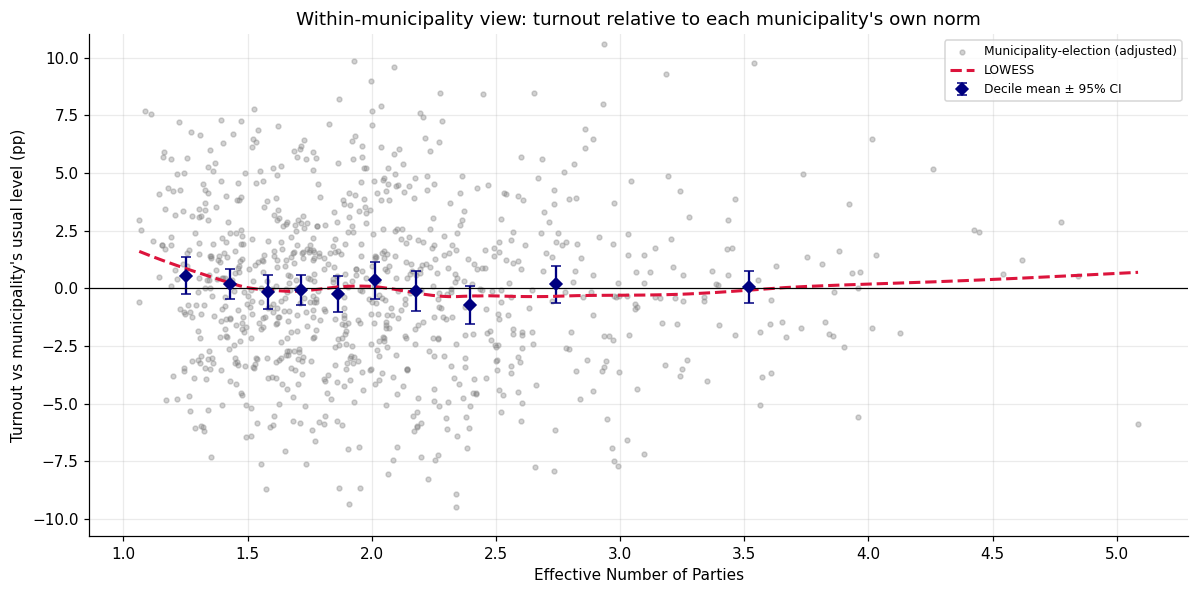

In [21]:
# Visualising the within test: we strip out each municipality's normal turnout level and
# each election's national swing, then plot what is left against fragmentation.
fe_only = smf.ols("turnout ~ C(year) + C(panel_id)", data=within).fit()
within["turnout_adj"] = fe_only.resid

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.scatter(within["enp"], within["turnout_adj"], s=10, color="grey", alpha=0.35,
           label="Municipality-election (adjusted)")
binned = (within.groupby(pd.qcut(within["enp"], 10), observed=True)
                .agg(x=("enp", "mean"), m=("turnout_adj", "mean"), se=("turnout_adj", "sem")))
ax.errorbar(binned["x"], binned["m"], yerr=1.96 * binned["se"], fmt="D", color="navy", ms=6, capsize=3,
            label="Decile mean ± 95% CI")
sm = lowess(within["turnout_adj"], within["enp"], frac=0.5)
ax.plot(sm[:, 0], sm[:, 1], color="crimson", lw=2, ls="--", label="LOWESS")
ax.axhline(0, color="black", lw=0.8)
ax.set(xlabel="Effective Number of Parties",
       ylabel="Turnout vs municipality's usual level (pp)",
       title="Within-municipality view: turnout relative to each municipality's own norm")
ax.set_ylim(np.percentile(within["turnout_adj"], [1, 99]) * 1.3)
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(FIG_DIR / "03_within_municipality.png", dpi=200, bbox_inches="tight")
plt.show()

## 9. Where competition changed most: 2011 → 2021
A journalist-friendly view: the municipalities whose fragmentation rose the most over the last decade, and how their turnout moved compared with the national shift.

In [22]:
# We compare each municipality's 2011 and 2021 values; turnout change is shown relative to
# the median national change, so the table isolates local movement from the national trend.
wide = panel[panel["year"].isin([2011, 2021])].pivot(index="panel_id", columns="year",
                                                      values=["enp", "turnout", "top_share"]).dropna()
change = pd.DataFrame({
    "name": latest_name.reindex(wide.index),
    "province": panel.drop_duplicates("panel_id", keep="last").set_index("panel_id")["province"].reindex(wide.index),
    "ENP 2011": wide[("enp", 2011)], "ENP 2021": wide[("enp", 2021)],
    "Δ ENP": wide[("enp", 2021)] - wide[("enp", 2011)],
    "turnout 2011": wide[("turnout", 2011)], "turnout 2021": wide[("turnout", 2021)],
})
national_shift = (change["turnout 2021"] - change["turnout 2011"]).median()
change["Δ turnout vs national (pp)"] = change["turnout 2021"] - change["turnout 2011"] - national_shift
print(f"Median turnout change 2011→2021 across {len(change)} matched municipalities: {national_shift:.1f} pp")
rho, p = stats.spearmanr(change["Δ ENP"], change["Δ turnout vs national (pp)"])
print(f"Correlation between change in ENP and relative turnout change: Spearman ρ = {rho:.2f} (p = {p:.3f})")
change.sort_values("Δ ENP", ascending=False).head(10).round(2)

Median turnout change 2011→2021 across 200 matched municipalities: -10.8 pp
Correlation between change in ENP and relative turnout change: Spearman ρ = -0.06 (p = 0.434)


,name,province,ENP 2011,ENP 2021,Δ ENP,turnout 2011,turnout 2021,Δ turnout vs national (pp)
panel_id,,,,,,,,
WC045,Oudtshoorn,Western Cape,2.51,5.09,2.57,62.11,44.17,-7.10
MP305,Lekwa,Mpumalanga,1.56,4.01,2.45,62.78,45.91,-6.04
JHB,City of Johannesburg,Gauteng,2.13,4.54,2.42,57.37,42.14,-4.40
WC053,Beaufort West,Western Cape,2.42,4.62,2.20,61.39,56.73,6.17
FS194,Maluti a Phofung,Free State,1.69,3.88,2.19,56.27,46.31,0.87
GT421,Emfuleni,Gauteng,1.76,3.83,2.06,61.42,43.57,-7.01
MP313,Steve Tshwete,Mpumalanga,1.84,3.86,2.02,58.02,43.63,-3.55
FS204,Metsimaholo,Free State,1.90,3.86,1.96,55.31,46.15,1.67
KZN252,Newcastle,KwaZulu-Natal,2.89,4.84,1.95,61.91,45.45,-5.63


## 10. Export for the modelling team

In [23]:
# The panel is the hand-off to modelling: one row per municipality per election, 2000–2021.
# We save it with the cleaning log so every number can be traced back to its source.
panel.to_csv(OUT_DIR / "lge_panel_2000_2021.csv", index=False)
per_year.to_csv(OUT_DIR / "inverted_u_by_year.csv")
panel_results.to_csv(OUT_DIR / "inverted_u_panel_models.csv")
print("Saved to outputs/: lge_panel_2000_2021.csv, cleaning_log.csv, inverted_u_by_year.csv, inverted_u_panel_models.csv")
print("Saved to figures/:", ", ".join(sorted(p.name for p in FIG_DIR.glob("*.png"))))

Saved to outputs/: lge_panel_2000_2021.csv, cleaning_log.csv, inverted_u_by_year.csv, inverted_u_panel_models.csv
Saved to figures/: 01_trends_2000_2021.png, 02_turnout_vs_enp_by_year.png, 03_within_municipality.png


## 11. Key findings

**1. Local politics has become far more competitive.** In 2000, 70% of municipalities were dominated by one party (ENP < 2) and only 1% were fragmented (ENP ≥ 3). By 2021 that had flipped to 16% dominant and 31% fragmented. Median ENP rose from 1.83 to 2.59, and the leading party's median vote share fell from 70% to 55%.

**2. Turnout fell sharply in 2021.** Median municipal turnout was about 53% in 2000 and 2006, peaked at 60% in 2011, then fell to 48% in 2021, a drop of 10.8 points across the 200 municipalities we can match between 2011 and 2021.

**3. The inverted U does not hold in any single election.** Testing each election separately with the Lind–Mehlum test, the inverted U is borderline in 2000 (p = 0.06) and absent in 2006, 2011 and 2021 (p = 0.42 to 0.96). An earlier version of this analysis found a significant curve in 2021 (p = 0.04), but that result disappeared once the missing Western Cape municipalities were restored, showing how incomplete data can create a pattern that is not really there.

**4. The pooled curve is driven by time and region.** Pooling all elections gives a weak inverted U (p = 0.03), mostly because 2021 was both the most fragmented and the lowest-turnout election. Controlling for the election year removes it (p = 0.39), and adding province leaves no trace of it (p = 0.97).

**5. Within the same municipality, there is no inverted U.** When a municipality becomes more or less fragmented over time, its turnout does not follow the hypothesised curve (inverted-U p = 0.98), and fragmentation explains under 1% of a municipality's turnout changes. Single-party dominance shows no within-municipality effect either (p = 0.58).

**6. Where fragmentation grew most, turnout did not fall more.** Between 2011 and 2021, the municipalities whose ENP rose the most (e.g. Oudtshoorn, Lekwa, Johannesburg) saw turnout changes similar to everyone else (Spearman ρ = −0.06, p = 0.43).

### What this means for our project
Our starting hypothesis, that turnout follows an inverted U against political competition, is **not supported** by 21 years of data. Turnout is driven by the national election-to-election swing and by stable regional differences, not by how competitive a municipality is. What the data *does* show very strongly is the rise of fragmentation itself: one-party dominance has collapsed, and far more councils now sit near or below the 50% majority line. This is why our model focuses on **forecasting hung councils in 2026** (see the machine learning notebook).

## 12. Data limitations
- **2016 turnout is excluded.** The cleaned 2016 turnout column divides only the leading party's votes by registered voters (for Johannesburg, 25.18% instead of the true 56.87%), so its implied denominator is a median 1.8× the 2011 voter roll. We keep 2016 for competition measures and exclude its turnout. Correct 2016 turnout can be recomputed from the raw file as (all valid votes + spoilt votes) ÷ registered voters; we note this as future work so the analysis stays reproducible as submitted.
- **2021 Western Cape (resolved).** An earlier combined 2021 file had been saved through Excel and was cut off at the 1,048,576-row limit, leaving only 3 of the 25 Western Cape municipalities, which briefly produced a false inverted U in 2021. `01_cleaning_2021` now combines the nine provincial IEC files in code, and a completeness check confirms all 213 municipalities. Lesson for the pipeline: large election files should be combined in code, never in Excel.
- **Boundary changes.** Municipalities were merged and redrawn in 2006, 2011 and 2016. Our name-and-code linking treats a municipality as the same unit across years even when its boundaries shifted.
- **Turnout definitions.** 2000–2011 turnout is the IEC's published figure; 2021 is computed by us as (valid + spoilt) ÷ registered voters on the PR ballot. Small definitional differences are absorbed by the election fixed effects in the within models.
- **District Management Areas** (parks and reserves) and one misaligned 2006 row were removed; see `cleaning_log.csv`.
- **Aggregate data.** These are municipality-level patterns; they do not tell us how individual voters decide.